# **Ship Detention Models**

## Import Libraries ##

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, GridSearchCV, cross_val_predict
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix, make_scorer, recall_score,
                             precision_score, f1_score,roc_auc_score,accuracy_score,
                             ConfusionMatrixDisplay, precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone

from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, KMeansSMOTE
from imblearn.ensemble import BalancedRandomForestClassifier, RUSBoostClassifier, EasyEnsembleClassifier
from imblearn.under_sampling import (RandomUnderSampler, NearMiss,
                                     EditedNearestNeighbours, RepeatedEditedNearestNeighbours,
                                     NeighbourhoodCleaningRule)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, backend as K

## Load Dataset

In [2]:
file_name = 'final_cleaned_dataset.csv'

df = pd.read_csv(file_name)
pd.set_option("display.max_columns", None)

print(f"Dataset Dimensions: {df.shape}\n")
display(df.head())
print("\nData Types:")
print(df.dtypes)

Dataset Dimensions: (16514, 13)



,Reporting Country,Port of Inspection,Ship Flag,Flag Performance List NUM,Description,Age_Category,Size_Category,Recognised Organisation (RO),RO Performance List NUM,Total Defficiencies in 36months,SUM of GroundsForDetention in 36months,Deficiency_Count,IsDetained
0,NO,Other,NL,0,Warship,2,2,115,0.0,2,0,0,0
1,NL,NLAMS,PA,1,Warship,2,2,169,0.0,1,0,4,0
2,NL,NLRTM,LR,0,Warship,2,3,121,0.0,1,0,9,0
3,NL,NLRTM,GR,0,Tanker,3,4,160,0.0,1,0,2,0
4,NL,NLAMS,LR,0,Warship,2,2,128,0.0,0,0,0,0



Data Types:
Reporting Country                          object
Port of Inspection                         object
Ship Flag                                  object
Flag Performance List NUM                   int64
Description                                object
Age_Category                                int64
Size_Category                               int64
Recognised Organisation (RO)               object
RO Performance List NUM                   float64
Total Defficiencies in 36months             int64
SUM of GroundsForDetention in 36months      int64
Deficiency_Count                            int64
IsDetained                                  int64
dtype: object


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16514 entries, 0 to 16513
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Reporting Country                       16514 non-null  object 
 1   Port of Inspection                      16514 non-null  object 
 2   Ship Flag                               16514 non-null  object 
 3   Flag Performance List NUM               16514 non-null  int64  
 4   Description                             16514 non-null  object 
 5   Age_Category                            16514 non-null  int64  
 6   Size_Category                           16514 non-null  int64  
 7   Recognised Organisation (RO)            16514 non-null  object 
 8   RO Performance List NUM                 16514 non-null  float64
 9   Total Defficiencies in 36months         16514 non-null  int64  
 10  SUM of GroundsForDetention in 36months  16514 non-null  in

## Missing Values & Duplicates Check

In [4]:
print('Missing Values: ')
print(df.isnull().sum(), '\n')
print('Duplicates Instances: ')
print(df.duplicated().sum())

Missing Values: 
Reporting Country                         0
Port of Inspection                        0
Ship Flag                                 0
Flag Performance List NUM                 0
Description                               0
Age_Category                              0
Size_Category                             0
Recognised Organisation (RO)              0
RO Performance List NUM                   0
Total Defficiencies in 36months           0
SUM of GroundsForDetention in 36months    0
Deficiency_Count                          0
IsDetained                                0
dtype: int64 

Duplicates Instances: 
471


In [5]:
df = df.drop_duplicates()
print('Duplicates Instances: ', df.duplicated().sum())
print('Duplicates Deleted')

Duplicates Instances:  0
Duplicates Deleted


## Separate Class & Features

In [6]:
X = df.drop(columns='IsDetained').copy()
y = df['IsDetained'].copy()

print(f"Features Selected: \n{X.columns}\n")
print(f"Features Dimensions: {X.shape}")

Features Selected: 
Index(['Reporting Country', 'Port of Inspection', 'Ship Flag',
       'Flag Performance List NUM', 'Description', 'Age_Category',
       'Size_Category', 'Recognised Organisation (RO)',
       'RO Performance List NUM', 'Total Defficiencies in 36months',
       'SUM of GroundsForDetention in 36months', 'Deficiency_Count'],
      dtype='object')

Features Dimensions: (16043, 12)


#**1. Traditional Algorithms**

## **1.1 Preprocessing Strategy**

To optimize the performance of the Machine Learning algorithms, **two different processing workflows (pipelines)** were designed, tailored to the mathematical requirements of each model family.

The features were divided into three categories:
1. **Pure Categorical:** Variables without a natural order (e.g., *Port of Inspection, Reporting Country*).
2. **Ordinal / Scaled:** Variables with a natural hierarchy (e.g., *Age Category: 1<2<3<4*).
3. **Counts:** Absolute numbers (e.g., *Deficiency Count*).

#### **1. Linear & Distance-Based Models (Logistic Regression, KNN)**
These algorithms rely on distance calculations (Euclidean) and linear combinations ($w \cdot x$).
* **Categorical:** **One-Hot Encoding** was applied to avoid creating false correlations between categories.
* **Ordinal:** **RobustScaler** was applied, facilitating the convergence of the Gradient Descent algorithm while maintaining the order of magnitude.
* **Counts:** **RobustScaler** was applied.

#### **2. Tree-Based Models (Random Forest, XGBoost, Decision Trees)**
Decision trees are not affected by the scale of the data, as they operate using splits rather than weight multiplications.
* **Categorical:** **Ordinal Encoding** was applied. This method is computationally more efficient and reduces dimensionality compared to One-Hot Encoding, allowing the trees to be built faster.
* **Ordinal & Counts:** Remained as is (**Passthrough**), as trees can naturally handle the order and magnitude of numbers.

### Create Lists With Features Categories

In [7]:
categorical_cols = [
    'Reporting Country',
    'Port of Inspection',
    'Ship Flag',
    'Description',
    'Recognised Organisation (RO)'
]

ordinal_cols = [
    'Flag Performance List NUM',
    'Age_Category',
    'Size_Category',
    'RO Performance List NUM'
]

count_cols = [
    'Total Defficiencies in 36months',
    'SUM of GroundsForDetention in 36months',
    'Deficiency_Count'
]

### Set Preprocessors

In [8]:
# PREPROCESSOR Linear
preprocessor_linear = ColumnTransformer(
    transformers=[
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols),

        ('ord', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ]), ordinal_cols),

        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ]), count_cols),
    ],
    remainder='drop'
)

# PREPROCESSOR TREE
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ]), categorical_cols),

        ('ord', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median'))
        ]), ordinal_cols),

        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median'))
        ]), count_cols),
    ],
    remainder='drop'
)

### Set Samplers & Classifiers

In [ ]:
# --- SAMPLERS ---
samplers = {
    'No_Sampling': None,

    # Undersampling
    'Random_Undersampling': RandomUnderSampler(random_state=42),
    'NearMiss': NearMiss(version=1),
    'ENN': EditedNearestNeighbours(),
    'NCR': NeighbourhoodCleaningRule(),

    # Oversampling
    'SMOTE': SMOTE(random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(kind='borderline-1', random_state=42),
    'KMeansSMOTE': KMeansSMOTE(cluster_balance_threshold=0.01, random_state=42),
}

# --- CLASSIFIERS ---
classifiers = {
    # Linear
    'LogReg': LogisticRegression(
        max_iter=3000,
        random_state=42,
        solver='lbfgs'
    ),
    'KNN': KNeighborsClassifier(),

    # Tree-based
    'RandomForest': RandomForestClassifier(
        random_state=42,
        n_estimators=300,
        n_jobs=1
    ),
    'DecisionTree': DecisionTreeClassifier(
        random_state=42,
    ),
    'XGBoost': XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        n_jobs=1
    ),

    # ensembles
    'BalancedRandomForest': BalancedRandomForestClassifier(
        random_state=42,
        n_estimators=300,
        n_jobs=1
    ),
    'RUSBoost': RUSBoostClassifier(random_state=42),
    'EasyEnsemble': EasyEnsembleClassifier(random_state=42, n_jobs=1)
}

# linear preprocessor
linear_models = {'LogReg', 'KNN'}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring_metrics = {
    'accuracy': 'accuracy',
    'auc': 'roc_auc',
    'recall': make_scorer(recall_score, pos_label=1, zero_division=0),
    'precision': make_scorer(precision_score, pos_label=1, zero_division=0),
    'f1': make_scorer(f1_score, pos_label=1, zero_division=0)
}

## **1.2 Fast Check of Different Sampling & Algorithm Combinations**

In [ ]:
# Header
header = f"{'Sampler':<22} | {'Classifier':<22} | {'AUC':<6} | {'Acc.':<6} | {'Recall':<6} | {'Prec.':<6} | {'F1':<6} | {'Time(s)':<8}"
print(header)
print("-" * len(header))

results = []

for sampler_name, sampler in samplers.items():
    for clf_name, clf in classifiers.items():

        # Skip logic for ensembles
        if clf_name in ['BalancedRandomForest', 'RUSBoost', 'EasyEnsemble'] and sampler_name != 'No_Sampling':
            continue

        # copy every new classifier to have it with its initial parameters
        current_clf = clone(clf)

        # balance weights for no sampling
        if sampler_name == 'No_Sampling':

            if 'class_weight' in current_clf.get_params():
                current_clf.set_params(class_weight='balanced')


            if clf_name == 'XGBoost':
                count_neg = (y == 0).sum()
                count_pos = (y == 1).sum()
                current_clf.set_params(scale_pos_weight=count_neg / count_pos)

        # PREPROCESSOR
        current_preprocessor = preprocessor_linear if clf_name in linear_models else preprocessor_tree

        # pipeline steps
        steps = [('preprocessor', current_preprocessor)]

        if sampler is not None:
            steps.append(('sampler', sampler))

        steps.append(('classifier', current_clf))

        model_pipeline = ImbPipeline(steps)

        # Cross Validation
        cv_results = cross_validate(
            model_pipeline,
            X, y,
            cv=cv,
            scoring=scoring_metrics,
            n_jobs=-1,
            return_train_score=False
        )

        # metrics mean
        auc_m  = float(np.nanmean(cv_results['test_auc']))
        acc_m  = float(np.nanmean(cv_results['test_accuracy']))
        rec_m  = float(np.nanmean(cv_results['test_recall']))
        prec_m = float(np.nanmean(cv_results['test_precision']))
        f1_m   = float(np.nanmean(cv_results['test_f1']))

        fit_m = float(np.nanmean(cv_results['fit_time']))
        sc_m  = float(np.nanmean(cv_results['score_time']))
        elapsed_time = fit_m + sc_m

        print(
            f"{sampler_name:<22} | {clf_name:<22} | "
            f"{auc_m:.4f} | {acc_m:.4f} | {rec_m:.4f} | {prec_m:.4f} | {f1_m:.4f} | {elapsed_time:.2f}"
        )

        results.append({
            'Sampler': sampler_name,
            'Classifier': clf_name,
            'AUC': auc_m,
            'Accuracy': acc_m,
            'Recall': rec_m,
            'Precision': prec_m,
            'F1': f1_m,
            'Time(s)': elapsed_time
        })

# save results
df_results = pd.DataFrame(results)
df_results = df_results[['Sampler','Classifier','AUC','Accuracy','Recall','Precision','F1','Time(s)']]

Sampler                | Classifier             | AUC    | Acc.   | Recall | Prec.  | F1     | Time(s) 
-------------------------------------------------------------------------------------------------------
No_Sampling            | LogReg                 | 0.9608 | 0.9278 | 0.8451 | 0.3329 | 0.4775 | 0.52
No_Sampling            | KNN                    | 0.8455 | 0.9731 | 0.4233 | 0.7919 | 0.5497 | 6.72
No_Sampling            | RandomForest           | 0.9438 | 0.9729 | 0.4025 | 0.8068 | 0.5356 | 6.20
No_Sampling            | DecisionTree           | 0.7357 | 0.9617 | 0.4905 | 0.5102 | 0.4994 | 0.41
No_Sampling            | XGBoost                | 0.9485 | 0.9627 | 0.6310 | 0.5217 | 0.5698 | 0.49
No_Sampling            | BalancedRandomForest   | 0.9548 | 0.9064 | 0.8450 | 0.2738 | 0.4135 | 4.23
No_Sampling            | RUSBoost               | 0.8836 | 0.9104 | 0.8148 | 0.3053 | 0.4309 | 0.18
No_Sampling            | EasyEnsemble           | 0.9608 | 0.8909 | 0.8754 | 0.2471 | 0.3852

### Best Combinations

In [ ]:
print("\n=== TOP 5 MODELS BASED ON Recall of class='Detained'")
display(df_results.sort_values(by='Recall', ascending=False).head(5))

print("\n=== TOP 5 MODELS BASED ON AUC")
display(df_results.sort_values(by='AUC', ascending=False).head(5))


=== TOP 5 MODELS BASED ON Recall of class='Detained'


,Sampler,Classifier,AUC,Accuracy,Recall,Precision,F1,Time(s)
10,Random_Undersampling,RandomForest,0.951817,0.879947,0.891390,0.231171,0.367061,1.614718
12,Random_Undersampling,XGBoost,0.951168,0.873403,0.884990,0.220845,0.353321,0.251646
7,No_Sampling,EasyEnsemble,0.960800,0.890918,0.875378,0.247056,0.385239,3.449579
8,Random_Undersampling,LogReg,0.961337,0.906127,0.873816,0.277750,0.421238,0.210559
9,Random_Undersampling,KNN,0.928759,0.871159,0.857854,0.213614,0.341949,0.659299



=== TOP 5 MODELS BASED ON AUC


,Sampler,Classifier,AUC,Accuracy,Recall,Precision,F1,Time(s)
18,ENN,LogReg,0.965481,0.974506,0.648648,0.686235,0.664746,12.906803
23,NCR,LogReg,0.964910,0.975316,0.618324,0.715745,0.661221,13.472327
8,Random_Undersampling,LogReg,0.961337,0.906127,0.873816,0.277750,0.421238,0.210559
7,No_Sampling,EasyEnsemble,0.960800,0.890918,0.875378,0.247056,0.385239,3.449579
0,No_Sampling,LogReg,0.960753,0.927819,0.845092,0.332946,0.477543,0.522124


Following an initial screening using default parameters, we obtain the results presented in the tables above. Our primary objective is to select a model that achieves a very high Recall for Class 1, while maintaining the highest possible Precision. To this end, the Precision-Recall curves for the combinations with indices 10, 12, 18, 23, 7, and 8 will be evaluated.

Subsequently, the two models demonstrating the best Precision-Recall trade-off will undergo Grid Search to optimize their hyperparameters. Finally, the decision threshold will be fine-tuned to align with our specific goal: minimizing the probability of missing a ship that should be detained (reducing False Negatives), while striving to keep Precision as high as possible.

In [34]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Model Definitions
models_config = {
    "Index 10: Random Undersampling + RForest": ImbPipeline([
        ('preprocessor', preprocessor_tree),
        ('sampler', RandomUnderSampler(random_state=42)),
        ('classifier', RandomForestClassifier(n_estimators=300, random_state=42))
    ]),
    "Index 12: Random Undersampling + XGBoost": ImbPipeline([
        ('preprocessor', preprocessor_tree),
        ('sampler', RandomUnderSampler(random_state=42)),
        ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
    ]),
    "Index 18: ENN + LogReg": ImbPipeline([
        ('preprocessor', preprocessor_linear),
        ('sampler', EditedNearestNeighbours()),
        ('classifier', LogisticRegression(max_iter=1000))
    ]),
    "Index 8: Random Undersampling + LogReg": ImbPipeline([
        ('preprocessor', preprocessor_linear),
        ('sampler', RandomUnderSampler(random_state=42)),
        ('classifier', LogisticRegression(max_iter=1000))
    ]),
    "Index 23: NCR + LogReg": ImbPipeline([
        ('preprocessor', preprocessor_linear),
        ('sampler', NeighbourhoodCleaningRule()),
        ('classifier', LogisticRegression(max_iter=1000))
    ]),
    "Index 7: EasyEnsemble": ImbPipeline([
        ('preprocessor', preprocessor_linear),
        ('classifier', EasyEnsembleClassifier(random_state=42))
    ])
}

Training Index 10: Random Undersampling + RForest...
Training Index 12: Random Undersampling + XGBoost...
Training Index 18: ENN + LogReg...
Training Index 8: Random Undersampling + LogReg...
Training Index 23: NCR + LogReg...
Training Index 7: EasyEnsemble...


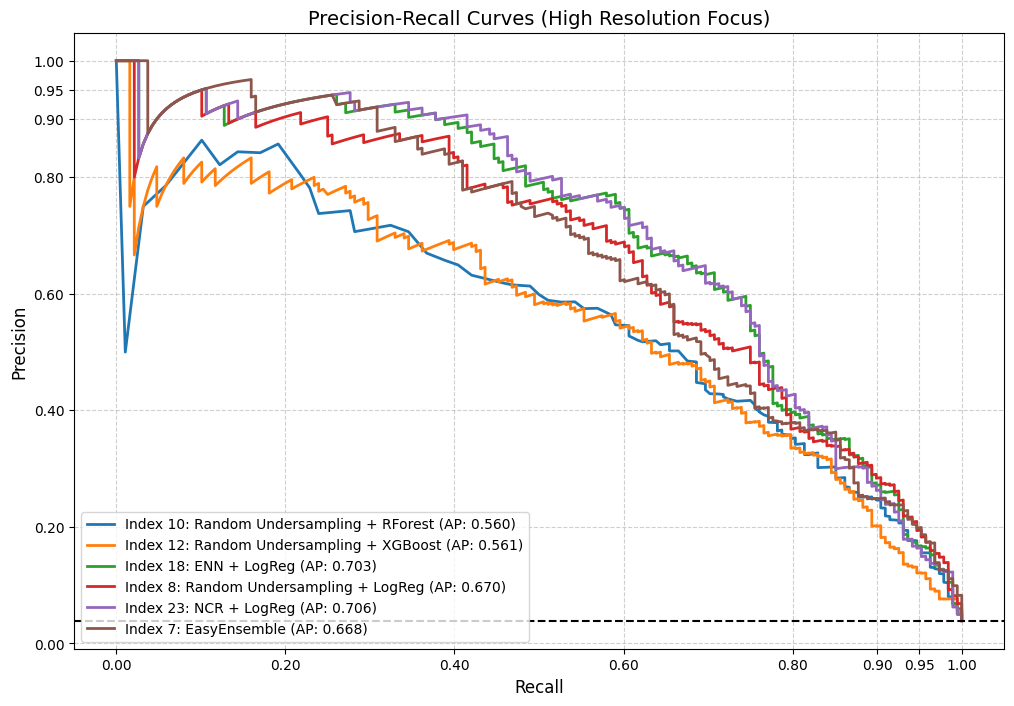


Model Name                               | Precision  | Threshold 
------------------------------------------------------------
Index 10: Random Undersampling + RForest | 0.2180    | 0.4600
Index 12: Random Undersampling + XGBoost | 0.1734    | 0.2205
Index 18: ENN + LogReg                   | 0.2613    | 0.0344
Index 8: Random Undersampling + LogReg   | 0.2739    | 0.4960
Index 23: NCR + LogReg                   | 0.2403    | 0.0277
Index 7: EasyEnsemble                    | 0.2436    | 0.5042


In [ ]:
# Training
trained_models = {}
for name, pipeline in models_config.items():
    print(f"Training {name}...")
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

# Plotting PRECISION RECALL Curves
def plot_pr_curves(models_dict, X_test, y_test):
    plt.figure(figsize=(12, 8))

    # Custom ticks to see near 0.90 clearly
    custom_ticks = [0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 1.0]

    for name, model in models_dict.items():
        probs = model.predict_proba(X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(y_test, probs)
        ap_score = average_precision_score(y_test, probs)

        plt.plot(recall, precision, label=f'{name} (AP: {ap_score:.3f})', lw=2)

    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curves (High Resolution Focus)', fontsize=14)
    plt.xticks(custom_ticks)
    plt.yticks(custom_ticks)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='lower left')

    # Baseline
    no_skill = len(y_test[y_test==1]) / len(y_test)
    plt.axhline(y=no_skill, color='black', linestyle='--', label='No Skill')
    plt.show()



plot_pr_curves(trained_models, X_test, y_test)

# --- 5. Threshold Analysis for Recall >= 91% ---
print("\n" + "="*60)
print(f"{'Model Name':<40} | {'Precision':<10} | {'Threshold':<10}")
print("-" * 60)

for name, model in trained_models.items():
    probs = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, probs)

    # Logic: Find where Recall is at least 0.91
    target_recall = 0.91
    idx = np.where(recall >= target_recall)[0]

    if len(idx) > 0:
        # Get the index with the highest precision in that range
        best_i = idx[np.argmax(precision[idx])]

        # Handle index edge case for thresholds
        thr = thresholds[best_i] if best_i < len(thresholds) else thresholds[-1]

        print(f"{name:<40} | {precision[best_i]:.4f}    | {thr:.4f}")
    else:
        print(f"{name:<40} | No point with 91% Recall found")

The combinations **Index 18 (ENN + LogReg)** and **Index 8 (Random Undersampling + LogReg)** were selected, as they achieve the highest possible Precision for Recall levels exceeding 91%. The next steps involve performing a Grid Search for both models, conducting overfitting assessments, and defining the optimal decision threshold to meet our requirements.

## **1.3 Tuning Best Models**


In [ ]:
logreg_param_grid = [
    {
        'classifier__solver': ['lbfgs'],
        'classifier__penalty': ['l2', None],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__max_iter': [2000, 5000]
    },
    {
        'classifier__solver': ['liblinear'],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__max_iter': [2000, 5000]
    },
    {
        'classifier__solver': ['saga'],
        'classifier__penalty': ['l1', 'l2', 'elasticnet'],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__max_iter': [2000, 5000],
        'classifier__l1_ratio': [0.5]
    }
]



models_to_tune = {
    "ENN_LogReg": {
        "pipeline": ImbPipeline([
            ('preprocessor', preprocessor_linear),
            ('sampler', EditedNearestNeighbours()),
            ('classifier', LogisticRegression(random_state=42))
        ]),
        "params": logreg_param_grid
    },
    "RandomUndersampling_LogReg": {
        "pipeline": ImbPipeline([
            ('preprocessor', preprocessor_linear),
            ('sampler', RandomUnderSampler(random_state=42)),
            ('classifier', LogisticRegression(random_state=42))
        ]),
        "params": logreg_param_grid
    }
}


cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_estimators = {}
grid_results = {}
exec_time = {}

for name, config in models_to_tune.items():
    print(f"\n{'#'*15} Tuning {name} {'#'*15}")

    start_time = time.time()

    grid = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        scoring='average_precision',
        cv=cv_strategy,
        n_jobs=-1,
        return_train_score=True
    )

    grid.fit(X_train, y_train)

    end_time = time.time()
    elapsed_time = end_time - start_time

    best_estimators[name] = grid.best_estimator_
    grid_results[name] = grid
    exec_time[name] = elapsed_time

# We put everything into a single dictionary
results_to_save = {
    'best_estimators': best_estimators,
    'grid_results': grid_results,
    'time': exec_time,
    'X_test': X_test,
    'y_test': y_test
}

# Save
joblib.dump(results_to_save, 'grid_search_final_results.joblib')


############### Tuning ENN_LogReg ###############

############### Tuning RandomUndersampling_LogReg ###############


['grid_search_final_results.joblib']

======= ENN_LogReg =======

Best Params: {'classifier__C': 1, 'classifier__max_iter': 2000, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Execution Time: 2665.747443675995 seconds
Train AP: 0.7649 | Test AP: 0.7181
Gap: 0.0468

======= RandomUndersampling_LogReg =======

Best Params: {'classifier__C': 1, 'classifier__max_iter': 2000, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Execution Time: 144.09067845344543 seconds
Train AP: 0.7179 | Test AP: 0.6879
Gap: 0.0300


========================= Final Threshold Optimization =========================

RESULTS FOR: ENN_LogReg
Threshold: 0.0300 | Precision: 0.2410 | Recall: 0.9309
              precision    recall  f1-score   support

           0     0.9968    0.8809    0.9353      4625
           1     0.2410    0.9309    0.3829       188

    accuracy                         0.8828      4813
   macro avg     0.6189    0.9059    0.6591      4813
weighted avg     0.9673    0.8828    0.9137      4813



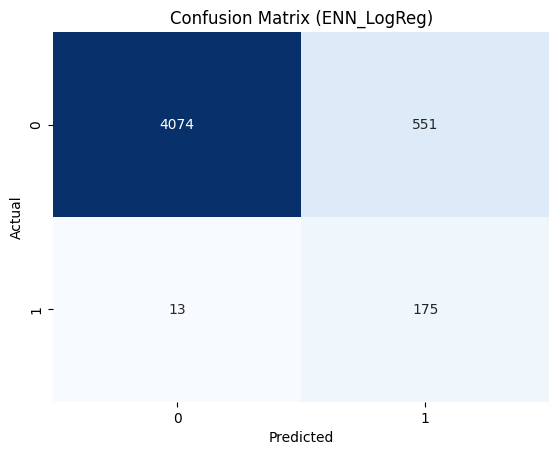


RESULTS FOR: RandomUndersampling_LogReg
Threshold: 0.4568 | Precision: 0.2581 | Recall: 0.9309
              precision    recall  f1-score   support

           0     0.9969    0.8912    0.9411      4625
           1     0.2581    0.9309    0.4042       188

    accuracy                         0.8928      4813
   macro avg     0.6275    0.9110    0.6726      4813
weighted avg     0.9680    0.8928    0.9201      4813



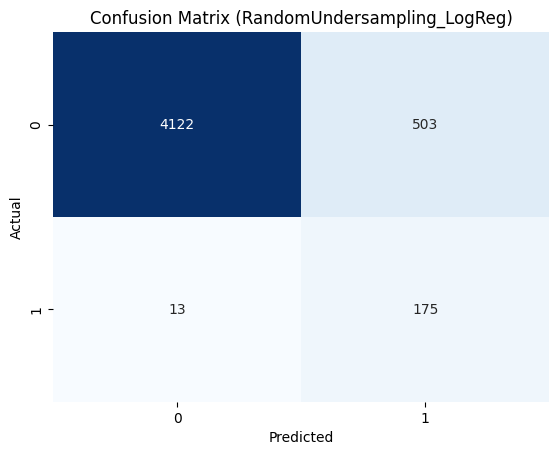

In [ ]:
# Load the results
loaded_data = joblib.load('grid_search_final_results.joblib')

# Extract individual components back to variables
best_estimators = loaded_data['best_estimators']
grid_results = loaded_data['grid_results']
time = loaded_data['time']
X_test = loaded_data['X_test']
y_test = loaded_data['y_test']

for name, grid in grid_results.items():
    # Check for Overfitting
    train_ap = grid.cv_results_['mean_train_score'][grid.best_index_]
    test_ap = grid.cv_results_['mean_test_score'][grid.best_index_]

    print(f"======= {name} =======\n")
    print(f"Best Params: {grid.best_params_}")
    print(f"Execution Time: {time[name]:.0f} seconds")
    print(f"Train AP: {train_ap:.4f} | Test AP: {test_ap:.4f}")
    print(f"Gap: {abs(train_ap - test_ap):.4f}\n")


# Threshold (Recall > 93%)
print("\n" + "="*25 + " Final Threshold Optimization " + "="*25)
target_recall = 0.93

for name, model in best_estimators.items():
    probs = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, probs)

    # index where recall is at least 93%
    idx = np.where(recall >= target_recall)[0]

    # for recall values > target_recall, we take the max precision
    best_idx = idx[np.argmax(precision[idx])]
    chosen_threshold = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]

    print(f"\nRESULTS FOR: {name}")
    print(f"Threshold: {chosen_threshold:.4f} | Precision: {precision[best_idx]:.4f} | Recall: {recall[best_idx]:.4f}")

    y_pred = (probs >= chosen_threshold).astype(int)
    print(classification_report(y_test, y_pred, digits=4))

    #confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix ({name})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

##**1.4 Final Model Selection: Random Undersampling + Logistic Regression**

The Random Undersampling + Logistic Regression configuration is selected as the optimal solution for this task due to its superior balance of sensitivity and operational efficiency.

- **Precision-Recall Trade-off:** The model achieves a 93% Recall with a 25.8% Precision. This ensures that the vast majority of high-risk vessels are identified while keeping false alarms within manageable operational limits.

- **Massive Efficiency Gains:** There is a significant difference in computational cost. This model required only 144 seconds to train, compared to 2666 seconds for the ENN + LogReg approach, making it roughly 18 times faster without sacrificing performance in the 93% recall range.


###**Moving Toward Deep Learning**

While a 93% "catch rate" is robust, the current precision leaves room for improvement. To further enhance Precision at these high sensitivity levels and reduce the burden of false positives, we will now explore Deep Learning architectures.

#**2. Neural Networks (Deep Learning)**

##**2.1 Deep Learning Data Preprocessing**

Artificial Neural Networks (ANNs), although non-linear models, share the same input requirements as Logistic Regression, as their training is based on the Backpropagation algorithm and weight optimization via Gradient Descent.

For this reason, the following transformation strategy was adopted:

1.  **Categorical Data: One-Hot Encoding** was applied. Neural networks cannot process strings or arbitrary integer codes without misinterpreting their magnitude. Converting them into 0 and 1 vectors (Sparse/Dense Vectors) allows the network to learn the weight of each category independently.

2.  **Ordinal Data (Scale 1 to 4): StandardScaler** (Z-score normalization) was applied. Standardizing these values is critical for training stability, as it prevents the saturation of activation functions (e.g., Sigmoid/Tanh) and accelerates the convergence of the loss function.

3.  **Numerical Data (Counts):** These were kept in their original scale (Passthrough), in accordance with the selected analytical methodology.

Finally, all data were cast to the float32 data type, which is the standard for optimal performance in TensorFlow and Keras libraries, ensuring high-speed matrix multiplications.

In [35]:
# Linear Preprocessor
X_train_proc = preprocessor_linear.fit_transform(X_train)
X_test_proc = preprocessor_linear.transform(X_test)

# Transform to float32
X_train_proc = X_train_proc.astype('float32')
X_test_proc = X_test_proc.astype('float32')

# y to numpy arrays
y_train = y_train.astype('float32').values
y_test = y_test.astype('float32').values

# dimensions
input_dim = X_train_proc.shape[1]

print(f"\nDimensions Train Set: {X_train_proc.shape}")
print(f"\nDimensions Test Set:  {X_test_proc.shape}")
print(f"Neurons at Input Layer: {input_dim}")


Dimensions Train Set: (11230, 378)

Dimensions Test Set:  (4813, 378)
Neurons at Input Layer: 378


## **2.2 Training without SMOTE**

Weights --> 0: 0.52, 1: 32.05

=== STARTING TRAINING ===
Epoch 1/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 4.0985 - precision: 0.1195 - recall: 0.0376 - val_loss: 0.1651 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.4103 - precision: 0.1893 - recall: 0.0855 - val_loss: 0.1535 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.8127 - precision: 0.3459 - recall: 0.2406 - val_loss: 0.1354 - val_precision: 1.0000 - val_recall: 0.0213
Epoch 4/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.9761 - precision: 0.3574 - recall: 0.3426 - val_loss: 0.1233 - val_precision: 0.7273 - val_recall: 0.1277
Epoch 5/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.8536 - precision: 0.3388 - recall: 0.3617 - val_loss: 0.1227 - val_precision: 0.5652 - val_recall: 0.2766
Epoch 6/100
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.6958 - precision: 0.3309 - 

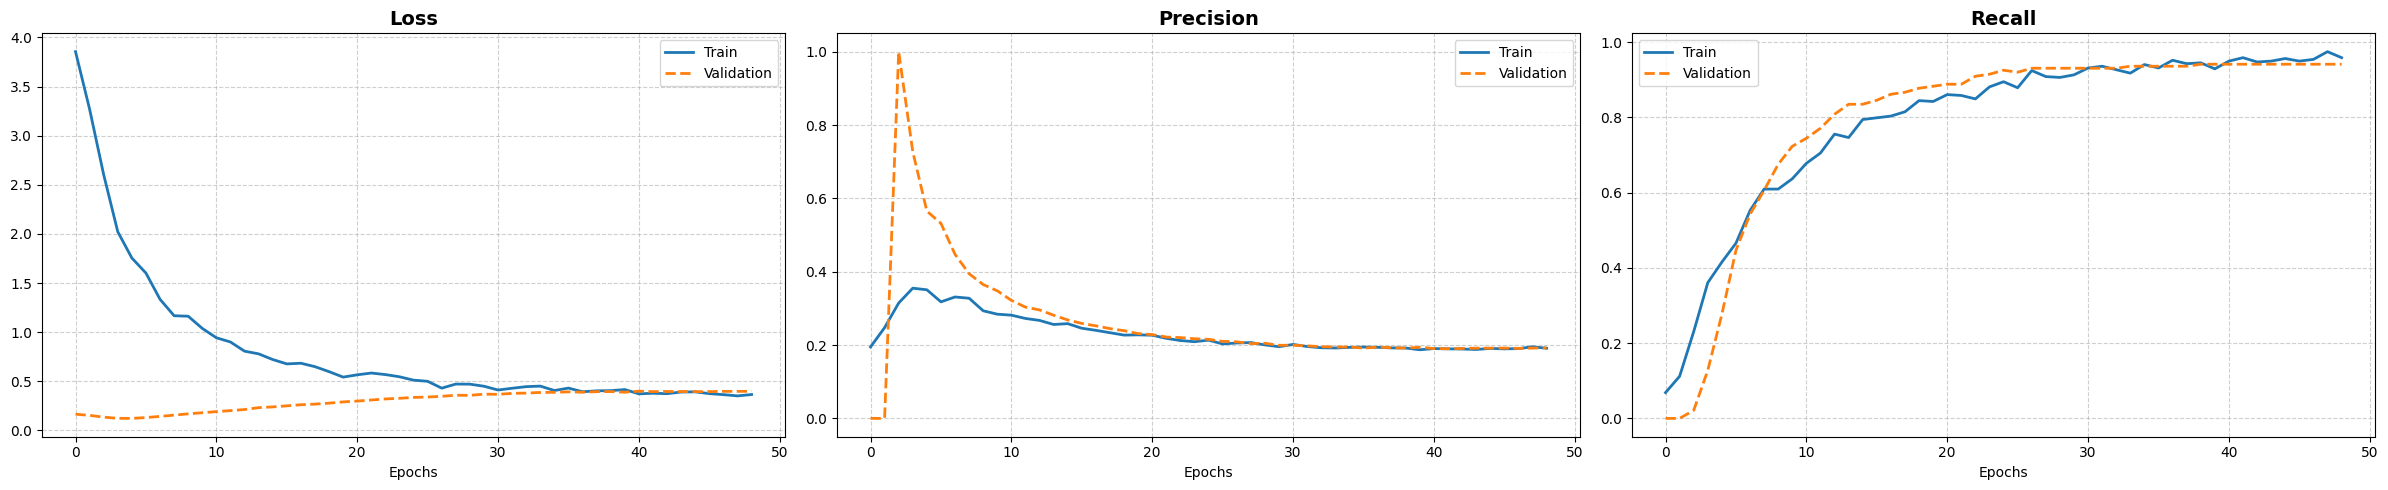

In [36]:
# CLASS WEIGHTS
neg, pos = np.bincount(y_train.astype(int))
total = neg + pos
weight_for_0 = (1 / neg) * (total / 2.0)

# we multiply by 2.5 to increase weight of class 1
weight_for_1 = ((1 / pos) * (total / 2.0)) * 2.5
class_weight = {0: weight_for_0, 1: weight_for_1}

print(f"Weights --> 0: {weight_for_0:.2f}, 1: {weight_for_1:.2f}")

# Bias Initialization
initial_bias = np.log([pos/neg])

def make_model(current_bias=None):
    if current_bias is not None:
        val = current_bias
    else:
        val = initial_bias

    output_bias = tf.keras.initializers.Constant(val)

    model = keras.Sequential([

        layers.Dense(64, activation='relu', input_shape=(X_train_proc.shape[1],)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(16, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(1, activation='sigmoid', bias_initializer=output_bias)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )
    return model

model = make_model()


early_stopping = callbacks.EarlyStopping(
    monitor='val_recall',
    patience=10,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

print("\n=== STARTING TRAINING ===")
history = model.fit(
    X_train_proc,
    y_train,
    batch_size=128,
    epochs=100,
    callbacks=[early_stopping],
    validation_data=(X_test_proc, y_test),
    class_weight=class_weight,
    verbose=1
)

# TRAIN-TEST PLOTS
metrics_to_plot = ['loss', 'precision', 'recall']
titles = ['Loss', 'Precision', 'Recall']

# 1 row, 3 columns
fig, ax = plt.subplots(1, 3, figsize=(24, 5))

for i, metric in enumerate(metrics_to_plot):

    if metric in history.history:
        # Plot Training Curve
        ax[i].plot(history.history[metric], label='Train', linewidth=2, color='tab:blue')

        # Plot Validation Curve
        if f'val_{metric}' in history.history:
            ax[i].plot(history.history[f'val_{metric}'], label='Validation', linewidth=2, linestyle='--', color='tab:orange')

        ax[i].set_title(titles[i], fontsize=14, fontweight='bold')
        ax[i].set_xlabel('Epochs')
        ax[i].legend()
        ax[i].grid(True, linestyle='--', alpha=0.6)
    else:
        ax[i].set_visible(False) # we hide blank graphs, if any
plt.tight_layout()
plt.show()


=== OPTIMIZING THRESHOLD FOR RECALL ===
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Report with Threshold = 0.1:
Classification Report for TRAIN set
              precision    recall  f1-score   support

Not Detained     1.0000    0.6646    0.7985     10792
    Detained     0.1079    1.0000    0.1948       438

    accuracy                         0.6776     11230
   macro avg     0.5540    0.8323    0.4967     11230
weighted avg     0.9652    0.6776    0.7749     11230

Classification Report for TEST set
              precision    recall  f1-score   support

Not Detained     0.9987    0.6547    0.7909      4625
    Detained     0.1033    0.9787    0.1869       188

    accuracy                         0.6674      4813
   macro avg     0.5510    0.8167    0.4889      4813
weighted avg     0.9637    0.6674    0.7673      4813



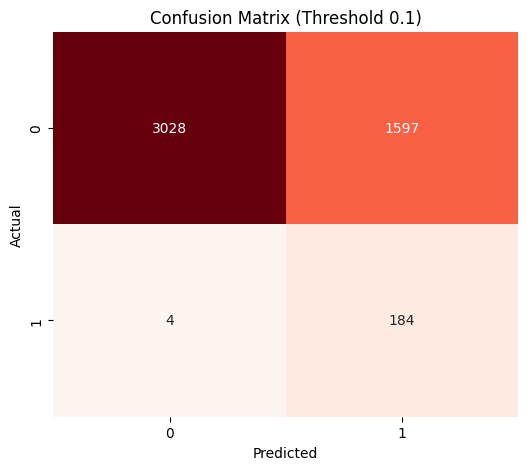


Report with Threshold = 0.2:
Classification Report for TRAIN set
              precision    recall  f1-score   support

Not Detained     0.9999    0.7409    0.8511     10792
    Detained     0.1352    0.9977    0.2381       438

    accuracy                         0.7509     11230
   macro avg     0.5675    0.8693    0.5446     11230
weighted avg     0.9661    0.7509    0.8272     11230

Classification Report for TEST set
              precision    recall  f1-score   support

Not Detained     0.9985    0.7338    0.8460      4625
    Detained     0.1294    0.9734    0.2285       188

    accuracy                         0.7432      4813
   macro avg     0.5640    0.8536    0.5372      4813
weighted avg     0.9646    0.7432    0.8218      4813



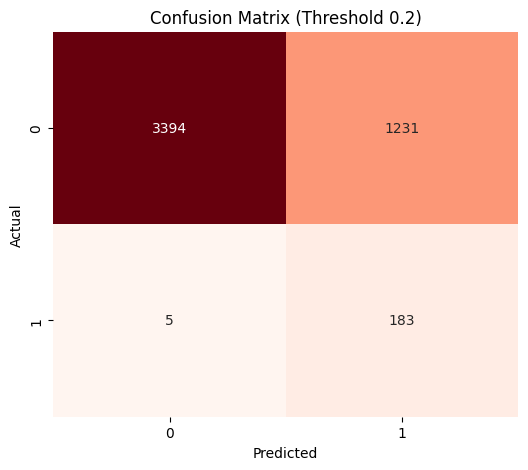


Report with Threshold = 0.3:
Classification Report for TRAIN set
              precision    recall  f1-score   support

Not Detained     0.9998    0.7867    0.8805     10792
    Detained     0.1592    0.9954    0.2746       438

    accuracy                         0.7948     11230
   macro avg     0.5795    0.8911    0.5775     11230
weighted avg     0.9670    0.7948    0.8569     11230

Classification Report for TEST set
              precision    recall  f1-score   support

Not Detained     0.9981    0.7801    0.8757      4625
    Detained     0.1511    0.9628    0.2612       188

    accuracy                         0.7872      4813
   macro avg     0.5746    0.8714    0.5685      4813
weighted avg     0.9650    0.7872    0.8517      4813



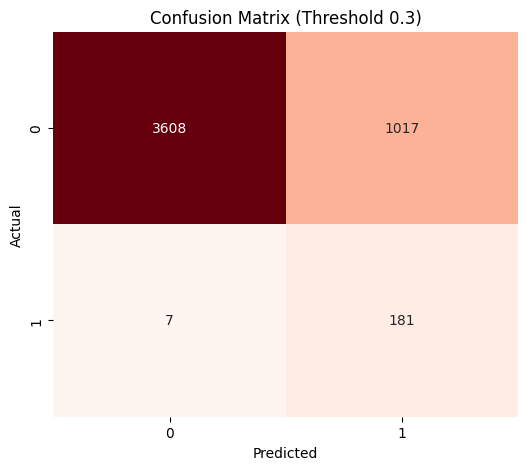


Report with Threshold = 0.4:
Classification Report for TRAIN set
              precision    recall  f1-score   support

Not Detained     0.9998    0.8165    0.8989     10792
    Detained     0.1805    0.9954    0.3055       438

    accuracy                         0.8235     11230
   macro avg     0.5901    0.9060    0.6022     11230
weighted avg     0.9678    0.8235    0.8758     11230

Classification Report for TEST set
              precision    recall  f1-score   support

Not Detained     0.9979    0.8089    0.8935      4625
    Detained     0.1692    0.9574    0.2875       188

    accuracy                         0.8147      4813
   macro avg     0.5835    0.8832    0.5905      4813
weighted avg     0.9655    0.8147    0.8698      4813



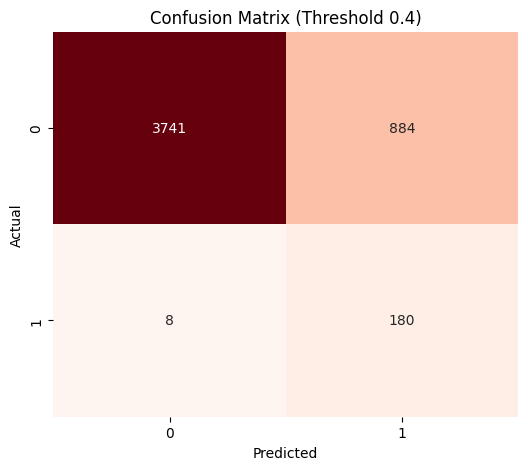


Report with Threshold = 0.5:
Classification Report for TRAIN set
              precision    recall  f1-score   support

Not Detained     0.9997    0.8435    0.9150     10792
    Detained     0.2048    0.9932    0.3396       438

    accuracy                         0.8493     11230
   macro avg     0.6022    0.9183    0.6273     11230
weighted avg     0.9687    0.8493    0.8925     11230

Classification Report for TEST set
              precision    recall  f1-score   support

Not Detained     0.9972    0.8387    0.9111      4625
    Detained     0.1918    0.9415    0.3186       188

    accuracy                         0.8427      4813
   macro avg     0.5945    0.8901    0.6149      4813
weighted avg     0.9657    0.8427    0.8880      4813



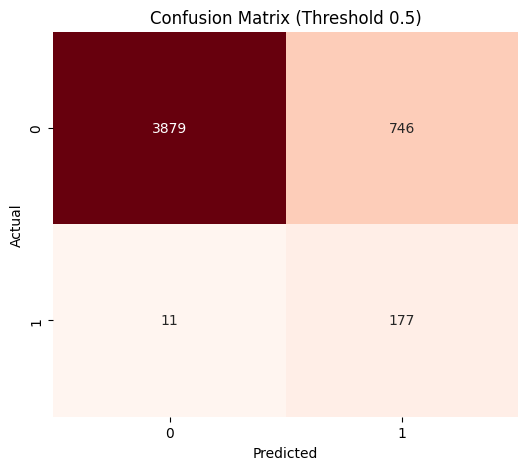

In [37]:
# THRESHOLD TUNING
print("\n=== OPTIMIZING THRESHOLD FOR RECALL ===")
y_pred_probs_train = model.predict(X_train_proc)
y_pred_probs_test = model.predict(X_test_proc)


for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:
    THRESHOLD = threshold

    y_pred_train = (y_pred_probs_train > THRESHOLD).astype(int)
    y_pred_test = (y_pred_probs_test > THRESHOLD).astype(int)

    print(f"\nReport with Threshold = {THRESHOLD}:")
    print('Classification Report for TRAIN set')
    print(classification_report(y_train, y_pred_train, digits=4, target_names=['Not Detained', 'Detained']))
    print('Classification Report for TEST set')
    print(classification_report(y_test, y_pred_test, digits=4, target_names=['Not Detained', 'Detained']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
    plt.title(f'Confusion Matrix (Threshold {THRESHOLD})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

##**2.3 Training with SMOTE**


############################################################
    TRAINING WITH RATIO: 90/10 (Light SMOTE) (Strategy=0.11)    
############################################################
Samples after SMOTE --> Class 0: 10792, Class 1: 1187

TRAINING GRAPHS FOR 90/10 (Light SMOTE)



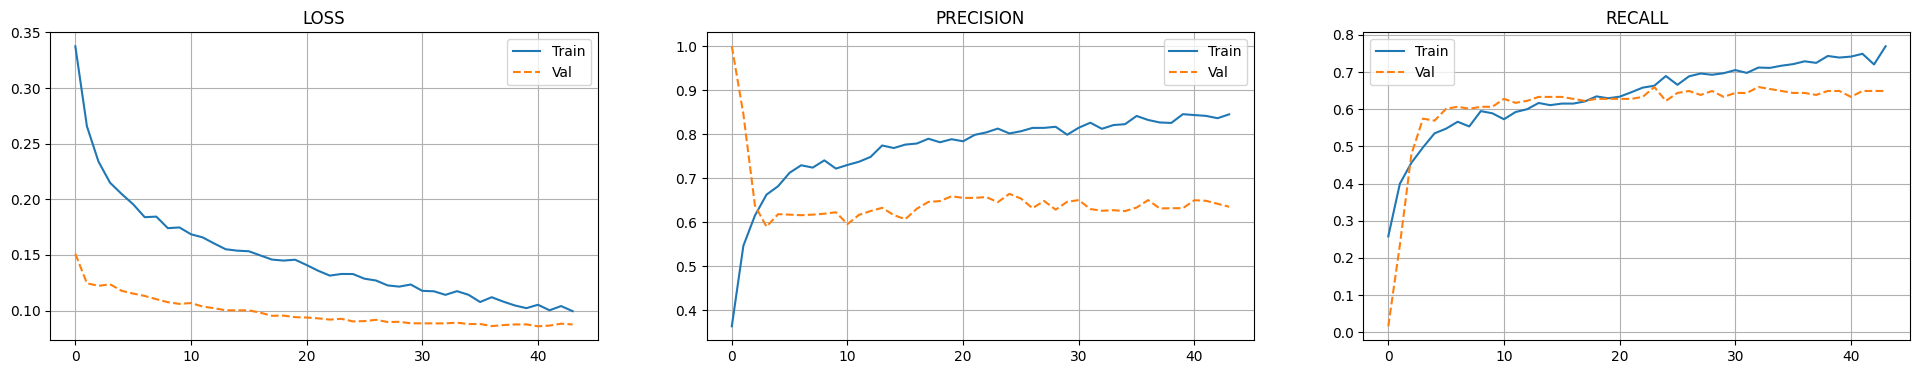

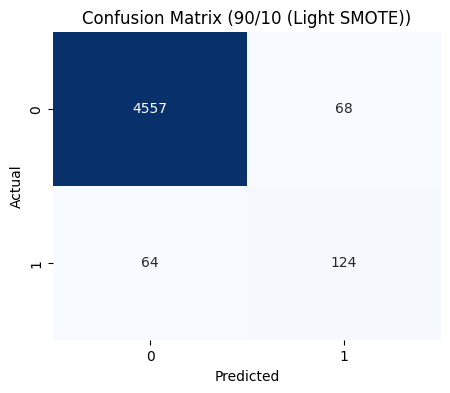

Classification Report (90/10 (Light SMOTE)):
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      4625
         1.0       0.65      0.66      0.65       188

    accuracy                           0.97      4813
   macro avg       0.82      0.82      0.82      4813
weighted avg       0.97      0.97      0.97      4813


############################################################
    TRAINING WITH RATIO: 80/20 (Moderate) (Strategy=0.25)    
############################################################
Samples after SMOTE --> Class 0: 10792, Class 1: 2698

TRAINING GRAPHS FOR 80/20 (Moderate)



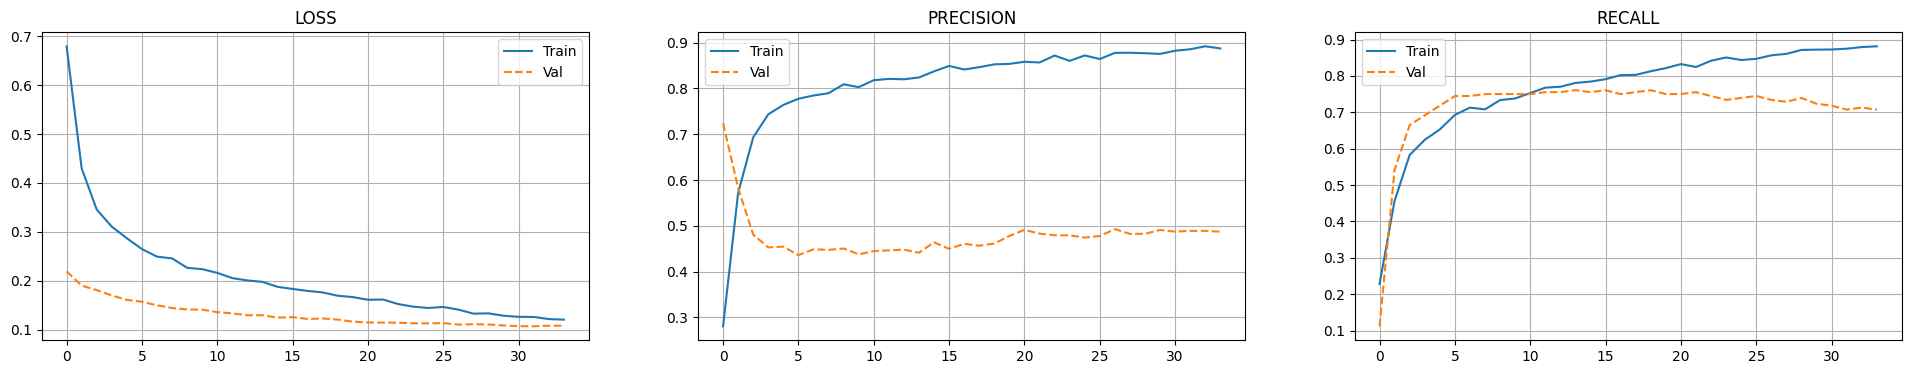

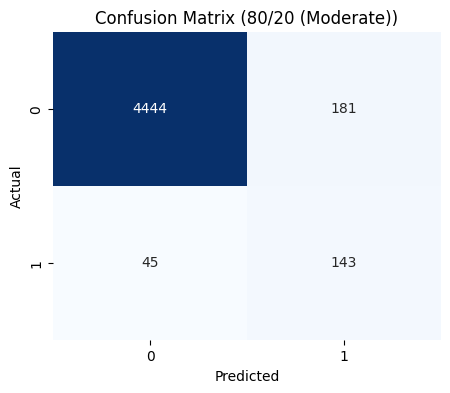

Classification Report (80/20 (Moderate)):
              precision    recall  f1-score   support

         0.0       0.99      0.96      0.98      4625
         1.0       0.44      0.76      0.56       188

    accuracy                           0.95      4813
   macro avg       0.72      0.86      0.77      4813
weighted avg       0.97      0.95      0.96      4813


############################################################
    TRAINING WITH RATIO: 70/30 (Strong) (Strategy=0.42)    
############################################################
Samples after SMOTE --> Class 0: 10792, Class 1: 4532

TRAINING GRAPHS FOR 70/30 (Strong)



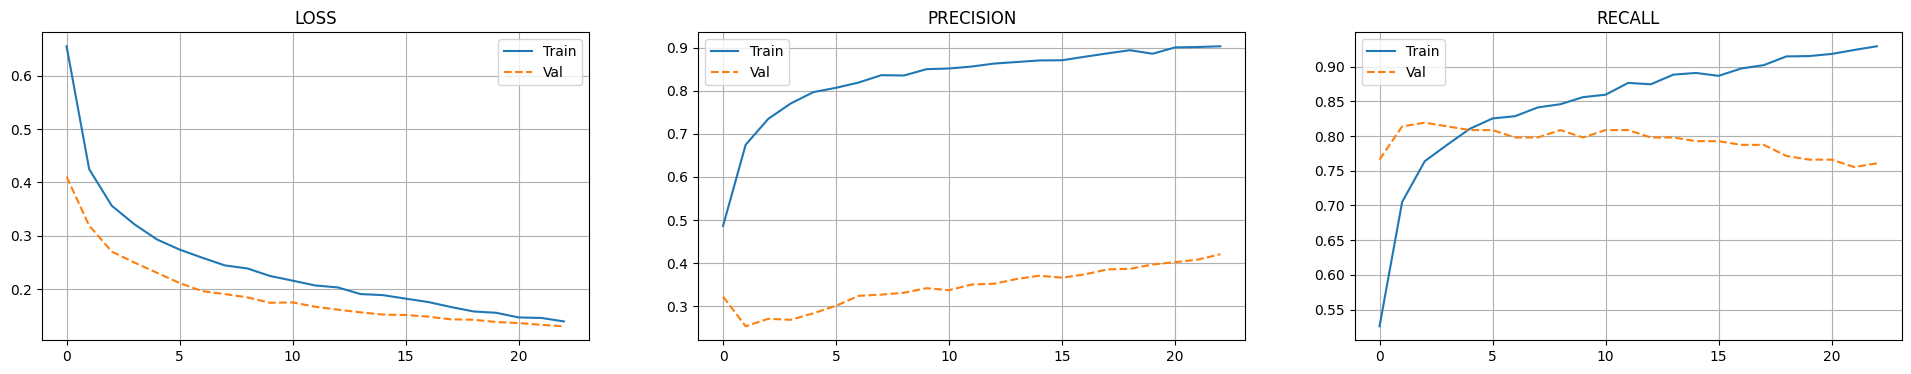

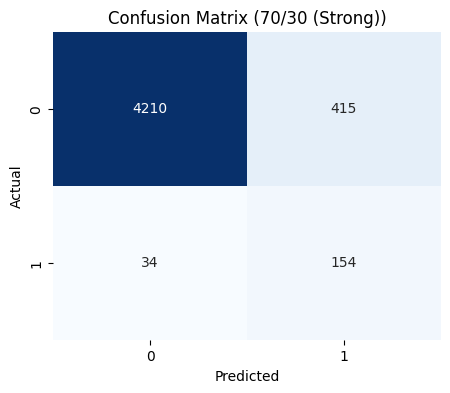

Classification Report (70/30 (Strong)):
              precision    recall  f1-score   support

         0.0       0.99      0.91      0.95      4625
         1.0       0.27      0.82      0.41       188

    accuracy                           0.91      4813
   macro avg       0.63      0.86      0.68      4813
weighted avg       0.96      0.91      0.93      4813


############################################################
    TRAINING WITH RATIO: 60/40 (Very Strong) (Strategy=0.66)    
############################################################
Samples after SMOTE --> Class 0: 10792, Class 1: 7122

TRAINING GRAPHS FOR 60/40 (Very Strong)



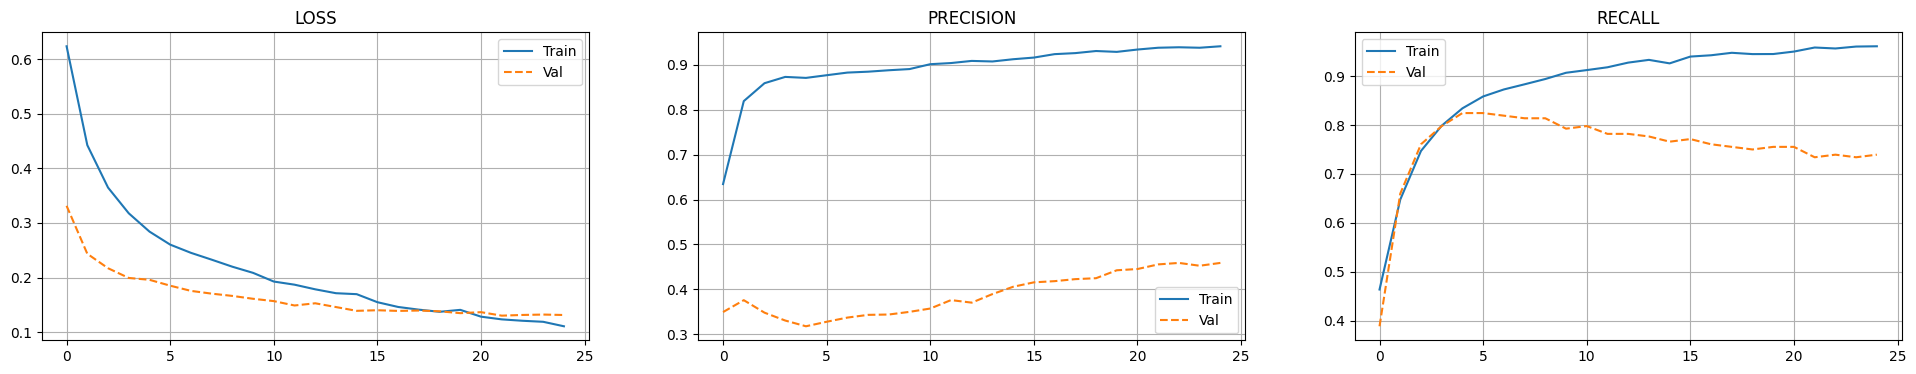

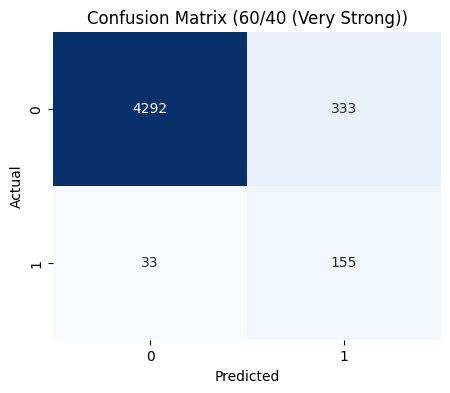

Classification Report (60/40 (Very Strong)):
              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96      4625
         1.0       0.32      0.82      0.46       188

    accuracy                           0.92      4813
   macro avg       0.65      0.88      0.71      4813
weighted avg       0.97      0.92      0.94      4813


############################################################
    TRAINING WITH RATIO: 50/50 (Full Balance) (Strategy=1.0)    
############################################################
Samples after SMOTE --> Class 0: 10792, Class 1: 10792

TRAINING GRAPHS FOR 50/50 (Full Balance)



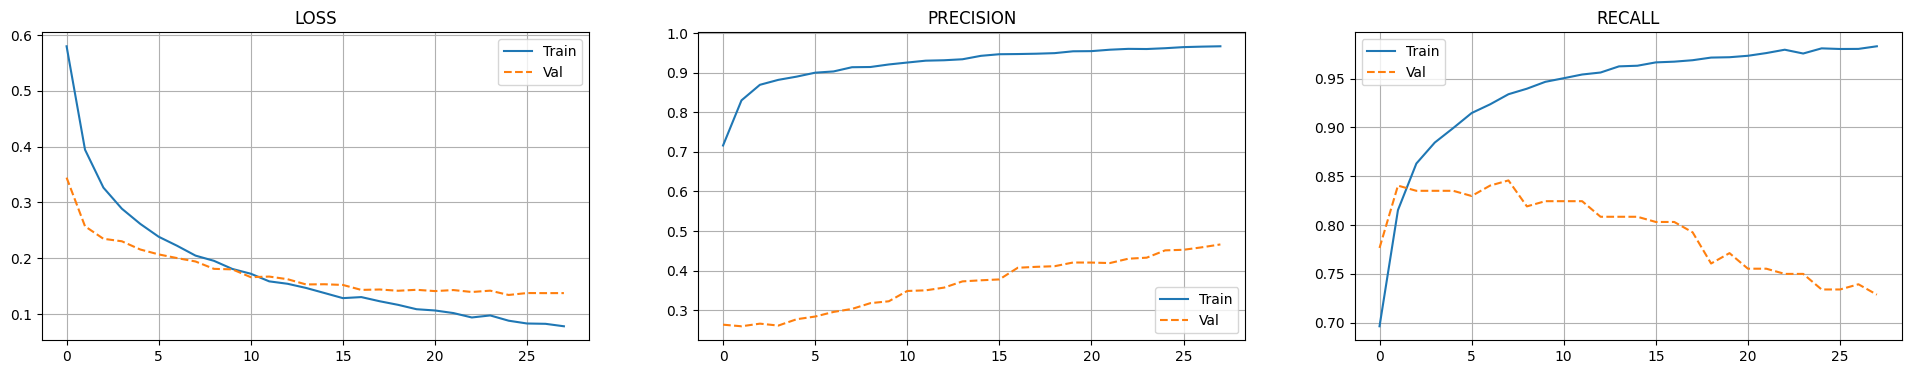

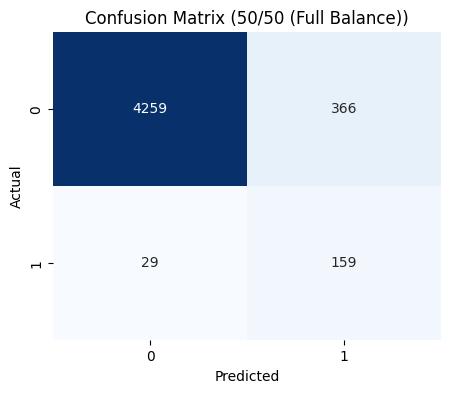

Classification Report (50/50 (Full Balance)):
              precision    recall  f1-score   support

         0.0       0.99      0.92      0.96      4625
         1.0       0.30      0.85      0.45       188

    accuracy                           0.92      4813
   macro avg       0.65      0.88      0.70      4813
weighted avg       0.97      0.92      0.94      4813



In [38]:
# we will try different ratios of synthetic data
smote_ratios = {
    '90/10 (Light SMOTE)': 0.11,
    '80/20 (Moderate)': 0.25,
    '70/30 (Strong)': 0.42,
    '60/40 (Very Strong)': 0.66,
    '50/50 (Full Balance)': 1.0
}


final_results = []

# loop for every ratio
for ratio_name, ratio_val in smote_ratios.items():

    print("\n" + "#"*60)
    print(f"    TRAINING WITH RATIO: {ratio_name} (Strategy={ratio_val})    ")
    print("#"*60)


    smote = SMOTE(sampling_strategy=ratio_val, random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

    print(f"Samples after SMOTE --> Class 0: {sum(y_train_res==0)}, Class 1: {sum(y_train_res==1)}")


    new_neg, new_pos = np.bincount(y_train_res.astype(int))
    new_bias = np.log([new_pos/new_neg])
    model = make_model(current_bias=new_bias)

    # Early Stopping
    early_stopping = callbacks.EarlyStopping(
        monitor='val_recall',
        patience=20,
        mode='max',
        restore_best_weights=True,
        verbose=0
    )

    # training
    history = model.fit(
        X_train_res,
        y_train_res,
        batch_size=64,
        epochs=80,
        callbacks=[early_stopping],
        validation_data=(X_test_proc, y_test),
        verbose=0
    )

    # plots for train and test data
    print(f"\nTRAINING GRAPHS FOR {ratio_name}\n")
    metrics_to_plot = ['loss', 'precision', 'recall']
    fig, ax = plt.subplots(1, 3, figsize=(24, 4))

    for i, metric in enumerate(metrics_to_plot):
        if metric in history.history:
            ax[i].plot(history.history[metric], label='Train')
            ax[i].plot(history.history[f'val_{metric}'], label='Val', linestyle="--")
            ax[i].set_title(metric.upper())
            ax[i].legend()
            ax[i].grid(True)
    plt.show()

    # EVALUATION & CONFUSION MATRIX
    y_pred_proba = model.predict(X_test_proc, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix ({ratio_name})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print(f"Classification Report ({ratio_name}):")
    print(classification_report(y_test, y_pred))

    # saving results for the final graph
    rec_class1 = recall_score(y_test, y_pred, pos_label=1)
    prec_class1 = precision_score(y_test, y_pred, pos_label=1)
    f1_class1 = f1_score(y_test, y_pred, pos_label=1)

    final_results.append({
        'Ratio': ratio_name,
        'Recall (Class 1)': rec_class1,
        'Precision (Class 1)': prec_class1,
        'F1 (Class 1)': f1_class1
    })


PERFORMANCE COMPARISON FOR DIFFERENT SMOTE RATIOS


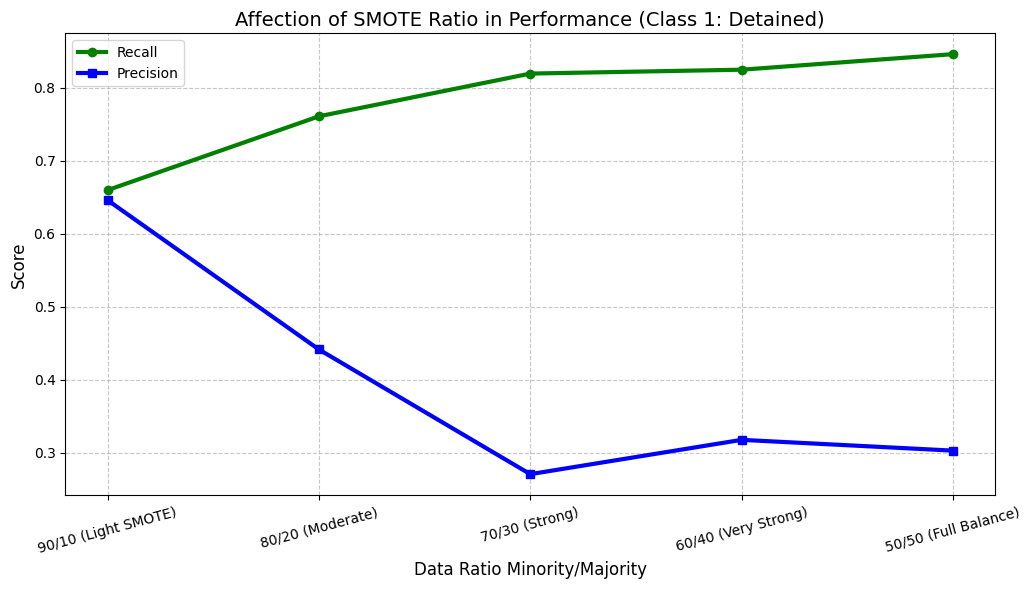

,Ratio,Recall (Class 1),Precision (Class 1),F1 (Class 1)
0,90/10 (Light SMOTE),0.659574,0.645833,0.652632
1,80/20 (Moderate),0.760638,0.441358,0.558594
2,70/30 (Strong),0.819149,0.270650,0.406869
3,60/40 (Very Strong),0.824468,0.317623,0.458580
4,50/50 (Full Balance),0.845745,0.302857,0.446003


In [39]:
# FINAL GRAPH
print("\n" + "="*50)
print("PERFORMANCE COMPARISON FOR DIFFERENT SMOTE RATIOS")
print("="*50)

results_df = pd.DataFrame(final_results)

plt.figure(figsize=(12, 6))
plt.plot(results_df['Ratio'], results_df['Recall (Class 1)'], marker='o', linewidth=3, label='Recall', color='green')
plt.plot(results_df['Ratio'], results_df['Precision (Class 1)'], marker='s', linewidth=3, label='Precision', color='blue')

plt.title('Affection of SMOTE Ratio in Performance (Class 1: Detained)', fontsize=14)
plt.xlabel('Data Ratio Minority/Majority', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=15)
plt.show()

print('\n')
display(results_df)

# **3. Conclusion & Project Summary**

This study systematically evaluated various predictive modeling methodologies for ship detention forecasting. The primary objective was to maximize navigational safety for maritime crews and proactively mitigate the risk of severe environmental disasters.

####**Methodological Approach & Experimentation**

A comprehensive comparative analysis was conducted, testing multiple combinations of data resampling techniques and traditional machine learning algorithms, alongside Deep Learning architectures. For the Artificial Neural Networks (ANNs), extensive hyperparameter tuning was executed. This included adjusting class weights (e.g., 1.5, 2.0, 2.5, 3.0), modifying network depth and width (number of hidden layers and neurons), and tuning operational parameters such as batch size and learning rate. Advanced loss functions, specifically Focal Loss, were implemented to address the severe class imbalance; however, these yielded suboptimal metrics. Furthermore, the application of SMOTE (Synthetic Minority Over-sampling Technique) on the neural network resulted in a significant degradation of performance compared to training on the original, un-resampled data with algorithmic class weighting.

####**Final Model Selection**

Ultimately, the Random Undersampling combined with Logistic Regression pipeline emerged as the most robust and effective model. It consistently achieved the highest overall scores across key evaluation metrics for both classes. At the optimal operating point, the model yielded the following indicative metrics:
- **Class 0 (Not Detained / Healthy):** Precision: 99.7% | Recall: 89.0%
- **Class 1 (Detained / High-Risk):** Precision: 25.8% | Recall: 93.0%

####**Threshold Optimization & Risk Justification**

To perfectly align the model with our critical operational priorities—specifically, maximizing the detection rate of high-risk vessels—decision threshold optimization was applied to the selected Logistic Regression model. A custom probability threshold of 0.4568 was strategically chosen. This adjustment deliberately sacrifices a fraction of Precision to secure a high Recall (93%) for the minority class.

While this trade-off inherently increases the False Positive rate—meaning some compliant vessels may face unjustified detentions or undergo more rigorous, time-consuming inspections—the model remains highly reliable. From a risk management perspective, this is a necessary and acceptable cost. The operational delay of inspecting a healthy ship is profoundly outweighed by the catastrophic consequences of a False Negative—namely, the potential loss of human life and irreversible environmental damage caused by allowing a substandard vessel to set sail.